# 04 - Full NER Data Pipeline

Single notebook that executes every data engineering step in the correct order:

```
1. Load raw dataset
2. Clean text
3. Split  (train 70 / val 15 / test 15)  — stratified by job category
4. BIO annotate all three splits via Gemini API
5. Tokenizer alignment for the selected model family
6. Export HuggingFace DatasetDict
```

**Why this order?** Cleaning and splitting happen before annotation so the LLM always sees clean text, and the splits are fixed before any labelling occurs.

**Output:** `data/processed/resume_ner_hf/` for BERT, or a model-specific folder such as `data/processed/resume_ner_hf_roberta-base/` for RoBERTa — a HuggingFace `DatasetDict` ready for model engineers.

## 1) Install dependencies

In [1]:
# Uncomment in Colab / fresh environment
# !pip -q install google-genai datasets transformers scikit-learn pandas seaborn matplotlib

## 2) Imports

In [1]:
import json
import os
import re
import time
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import Dataset, DatasetDict, Features, Sequence, Value, load_dataset
from google import genai
from google.genai import errors as genai_errors
from google.genai import types
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

/Users/alyani/Desktop/grad school/WQF7007/project/wqf7007-automated-cv-parser/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Configuration

In [2]:
# ── Gemini ────────────────────────────────────────────────────────────────────
GEMINI_MODEL = "gemini-3.1-flash-lite-preview"
CALL_DELAY   = 0.3   # seconds between calls — stays within ~15 RPM free-tier limit
MAX_RETRIES  = 3

# ── Dataset ──────────────────────────────────────────────────────────────────
DATASET_NAME      = "yashpwr/resume-ner-training-data"
CATEGORY_QUESTION = "What job category does this resume best fit?"
MAX_SAMPLES       = None   # None = use all available rows

# ── Split ────────────────────────────────────────────────────────────────────
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
RANDOM_SEED  = 42
MIN_CLASS_SAMPLES = 3   # classes below this are merged into OTHER before splitting

# ── NER labels ───────────────────────────────────────────────────────────────
LABEL_LIST = ["O", "B-JOB_TITLE", "I-JOB_TITLE", "B-SKILL", "I-SKILL", "B-EDUCATION", "I-EDUCATION"]
LABEL2ID   = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}
IGNORE_IDX = -100

# ── Tokenizer/model family ───────────────────────────────────────────────────
# Use "bert-base-uncased" for the existing BERT dataset, or "roberta-base" for RoBERTa.
MODEL_CHECKPOINT = "roberta-base"
MAX_LENGTH       = 512
STRIDE           = 128   # overlap between consecutive sliding-window chunks

# ── Output ───────────────────────────────────────────────────────────────────
TOKENIZER_FAMILY = "roberta" if "roberta" in MODEL_CHECKPOINT.lower() else "bert"
MODEL_OUTPUT_SUFFIX = "" if MODEL_CHECKPOINT == "bert-base-uncased" else f"_{MODEL_CHECKPOINT.replace('/', '-')}"
OUT_HF  = Path(f"../data/processed/resume_ner_hf{MODEL_OUTPUT_SUFFIX}")
OUT_CSV = Path("../data/processed/resume_bio_annotated_full.csv")
OUT_HF.parent.mkdir(parents=True, exist_ok=True)

print("Config loaded.")
print(f"Label map: {LABEL2ID}")
print(f"Effective rate : ~{60/CALL_DELAY:.1f} RPM")
print(f"Tokenizer family: {TOKENIZER_FAMILY}")
print(f"Sliding window : max_length={MAX_LENGTH}, stride={STRIDE}")
print(f"HF output path : {OUT_HF}")

Config loaded.
Label map: {'O': 0, 'B-JOB_TITLE': 1, 'I-JOB_TITLE': 2, 'B-SKILL': 3, 'I-SKILL': 4, 'B-EDUCATION': 5, 'I-EDUCATION': 6}
Effective rate : ~200.0 RPM
Tokenizer family: roberta
Sliding window : max_length=512, stride=128
HF output path : ../data/processed/resume_ner_hf_roberta-base


## 4) Gemini client setup

In Colab: add `GEMINI_API_KEY` to **Secrets** (key icon, left sidebar).  
Locally: set it as an environment variable.

In [3]:
if not OUT_CSV.exists():
    try:
        from google.colab import userdata
        GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
    except Exception:
        GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")

    if not GEMINI_API_KEY:
        raise ValueError("GEMINI_API_KEY not set.")

    gemini_client = genai.Client(api_key=GEMINI_API_KEY)
    print(f"Gemini client ready — model: {GEMINI_MODEL}")
else:
    gemini_client = None
    print(f"Annotated CSV already exists at {OUT_CSV} — Gemini client not needed.")


Annotated CSV already exists at ../data/processed/resume_bio_annotated_full.csv — Gemini client not needed.


---
## STEP 1 — Load raw dataset

In [4]:
print("Loading dataset from HuggingFace ...")
raw_dataset = load_dataset(DATASET_NAME)

cat_re = re.compile(r"best fits the\s+([A-Z\-]+)\s+category", re.IGNORECASE)

def get_msg(example, role):
    for m in example["messages"]:
        if m["role"] == role:
            return m["content"]
    return ""

records = []
for ex in raw_dataset["train"]:
    user  = get_msg(ex, "user")
    lines = user.strip().splitlines()
    if not lines or lines[0] != CATEGORY_QUESTION:
        continue
    m = cat_re.search(get_msg(ex, "assistant"))
    if not m:
        continue
    # Case-insensitive split on "resume:"
    parts  = re.split(r"resume:", user, maxsplit=1, flags=re.IGNORECASE)
    resume = parts[1].strip() if len(parts) > 1 else user.strip()
    records.append({"resume_text": resume, "job_category": m.group(1).upper()})

df_raw = pd.DataFrame(records)
if MAX_SAMPLES:
    df_raw = df_raw.head(MAX_SAMPLES)

print(f"Extracted rows : {len(df_raw):,}")
print(f"Unique categories: {df_raw['job_category'].nunique()}")
df_raw.head(3)

Loading dataset from HuggingFace ...


Extracted rows : 2,483
Unique categories: 24


,resume_text,job_category
0,What job category does this resume best fit?\n...,TEACHER
1,What job category does this resume best fit?\n...,HR
2,What job category does this resume best fit?\n...,ADVOCATE


---
## STEP 2 — Clean text

In [5]:
def clean_resume(text: str) -> str:
    # Drop non-UTF-8 characters
    text = text.encode("utf-8", errors="ignore").decode("utf-8")
    # Collapse 3+ newlines to 2
    text = re.sub(r"\n{3,}", "\n\n", text)
    # Collapse multiple spaces / tabs to single space
    text = re.sub(r"[ \t]+", " ", text)
    # Strip leading/trailing whitespace per line
    text = "\n".join(line.strip() for line in text.splitlines())
    return text.strip()

df_raw["resume_text"] = df_raw["resume_text"].apply(clean_resume)

# Sanity check — no empty resumes after cleaning
empty = (df_raw["resume_text"].str.strip() == "").sum()
assert empty == 0, f"{empty} empty resumes after cleaning"

print(f"Cleaning done. Avg length: {df_raw['resume_text'].str.len().mean():.0f} chars")

Cleaning done. Avg length: 5978 chars


---
## STEP 3 — Split (stratified 70 / 15 / 15)

Classes with fewer than `MIN_CLASS_SAMPLES` rows cannot be stratified across three splits.  
These are temporarily merged into `OTHER` for splitting, then the original label is restored.

Class distribution:
job_category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ADVOCATE                  118
ACCOUNTANT                118
CHEF                      118
ENGINEERING               118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
BANKING                   115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


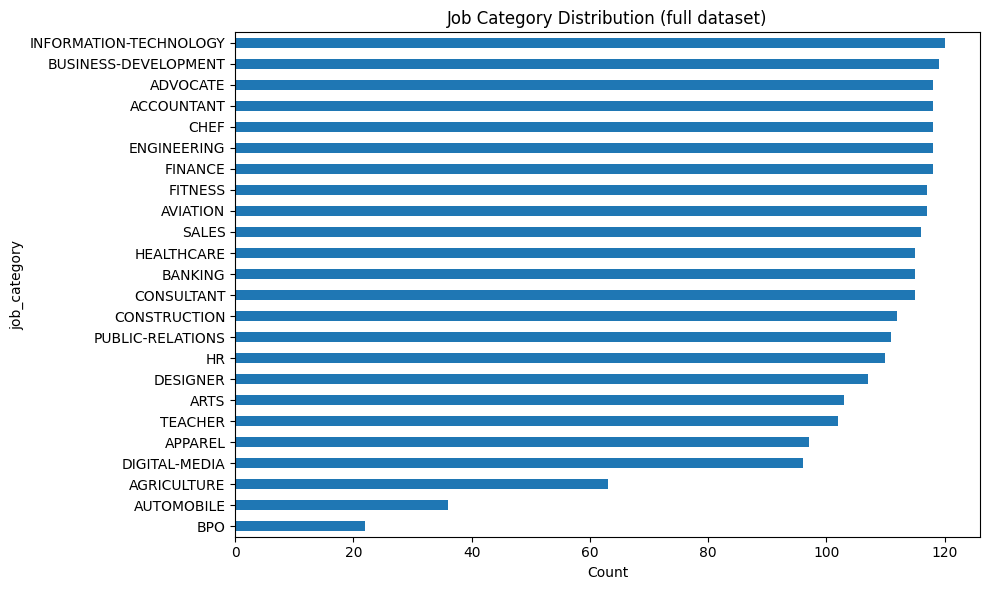


All classes have enough samples for stratification.


In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
counts = df_raw["job_category"].value_counts()
print("Class distribution:")
print(counts.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Job Category Distribution (full dataset)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

small_classes = counts[counts < MIN_CLASS_SAMPLES].index.tolist()
if small_classes:
    print(f"\nClasses merged into OTHER for splitting (< {MIN_CLASS_SAMPLES} samples): {small_classes}")
else:
    print("\nAll classes have enough samples for stratification.")

In [7]:
# ── Temporary stratification label ───────────────────────────────────────────
df_raw["_strat_label"] = df_raw["job_category"].apply(
    lambda c: "OTHER" if c in small_classes else c
)

# ── First split: (train+val) vs test ─────────────────────────────────────────
df_trainval, df_test = train_test_split(
    df_raw,
    test_size=TEST_RATIO,
    stratify=df_raw["_strat_label"],
    random_state=RANDOM_SEED,
)

# ── Second split: train vs val ────────────────────────────────────────────────
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_size_adjusted,
    stratify=df_trainval["_strat_label"],
    random_state=RANDOM_SEED,
)

# ── Clean up temp column ──────────────────────────────────────────────────────
for df in (df_train, df_val, df_test):
    df.drop(columns=["_strat_label"], inplace=True)
    df.reset_index(drop=True, inplace=True)

assert len(df_train) + len(df_val) + len(df_test) == len(df_raw)

print(f"Train : {len(df_train):>5,} rows  ({len(df_train)/len(df_raw):.0%})")
print(f"Val   : {len(df_val):>5,} rows  ({len(df_val)/len(df_raw):.0%})")
print(f"Test  : {len(df_test):>5,} rows  ({len(df_test)/len(df_raw):.0%})")

Train : 1,737 rows  (70%)
Val   :   373 rows  (15%)
Test  :   373 rows  (15%)


---
## STEP 4 — BIO annotation via Gemini API

All three splits are annotated separately and sequentially.  
The LLM is a frozen extractor — it is not trained on this data — so annotating val and test does not constitute data leakage.

In [8]:
# ── Gemini call ───────────────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are an expert CV parser. Extract named entities from resume text. "
    "Always respond with valid JSON only — no explanation, no markdown fences."
)

USER_TEMPLATE = """Extract all named entities from the resume below.
Return ONLY this JSON structure (use empty lists if nothing found):
{{
  "job_titles": ["..."],
  "skills": ["..."],
  "education": ["..."]
}}
Rules:
- job_titles: job roles/positions (e.g. "Software Engineer")
- skills: tools, languages, frameworks, certifications (e.g. "Python", "AWS")
- education: degree + institution or standalone degree (e.g. "B.Sc Computer Science")
- Copy spans EXACTLY as they appear in the text.

Resume:
{resume_text}"""


def call_gemini(text: str) -> dict | None:
    for attempt in range(MAX_RETRIES):
        try:
            resp = gemini_client.models.generate_content(
                model=GEMINI_MODEL,
                contents=USER_TEMPLATE.format(resume_text=text[:3000]),
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    response_mime_type="application/json",
                    temperature=0.0,
                    max_output_tokens=512,
                ),
            )
            # Extract text parts only — avoids warning when thinking models
            # include non-text parts like 'thought_signature' alongside the JSON
            text_content = "".join(
                part.text
                for part in resp.candidates[0].content.parts
                if hasattr(part, "text") and part.text
            )
            return json.loads(text_content)
        except genai_errors.ClientError as e:
            if e.status_code == 429:
                wait = 2 ** (attempt + 1)
                print(f"  rate limited — waiting {wait}s", flush=True)
                time.sleep(wait)
            else:
                print(f"  API error {e.status_code}: {e}", flush=True)
                return None
        except Exception as e:
            print(f"  error: {e}", flush=True)
            return None
    return None


# ── BIO conversion ────────────────────────────────────────────────────────────
ENTITY_LABEL_MAP = {
    "job_titles": "JOB_TITLE",
    "skills":     "SKILL",
    "education":  "EDUCATION",
}


def entities_to_bio(text: str, entities: dict) -> tuple[list[str], list[str]]:
    tokens = text.split()
    tags   = ["O"] * len(tokens)

    for field, label in ENTITY_LABEL_MAP.items():
        for ent in entities.get(field, []):
            if not ent or not ent.strip():
                continue
            span = ent.split()
            n    = len(span)
            for i in range(len(tokens) - n + 1):
                if [t.lower().strip(".,;:()") for t in tokens[i:i+n]] == \
                   [t.lower().strip(".,;:()") for t in span]:
                    if tags[i] == "O":
                        tags[i] = f"B-{label}"
                        for j in range(1, n):
                            if tags[i+j] == "O":
                                tags[i+j] = f"I-{label}"
    return tokens, tags


# ── Annotation loop ───────────────────────────────────────────────────────────
def annotate_split(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    rows   = []
    failed = []
    total  = len(df)

    print(f"\n{'='*60}")
    print(f"Annotating {split_name.upper()} split ({total} rows) ...")
    print(f"{'='*60}")

    for i, (_, row) in enumerate(df.iterrows()):
        text     = row["resume_text"]
        category = row["job_category"]

        entities = call_gemini(text)

        if entities is None:
            failed.append(i)
            print(f"[{i+1:>4}/{total}] FAILED  — {category}", flush=True)
            time.sleep(CALL_DELAY)
            continue

        tokens, tags = entities_to_bio(text, entities)
        non_o        = sum(1 for t in tags if t != "O")

        rows.append({
            "split":        split_name,
            "job_category": category,
            "resume_text":  text,
            "tokens":       json.dumps(tokens),
            "bio_tags":     json.dumps(tags),
            "entities_raw": json.dumps(entities),
        })

        skills_preview = entities.get("skills", [])[:3]
        print(f"[{i+1:>4}/{total}] OK  {category:<25} entities={non_o:>3}  skills={skills_preview}", flush=True)
        time.sleep(CALL_DELAY)

    print(f"\n{split_name.upper()} done — {len(rows)} annotated / {len(failed)} failed")
    return pd.DataFrame(rows)


print("Annotation functions ready.")

Annotation functions ready.


In [9]:
if OUT_CSV.exists():
    print(f"Annotations already exist — loading from {OUT_CSV.resolve()}")
    df_ann_all   = pd.read_csv(OUT_CSV)
    df_ann_train = df_ann_all[df_ann_all["split"] == "train"].reset_index(drop=True)
    df_ann_val   = df_ann_all[df_ann_all["split"] == "val"].reset_index(drop=True)
    df_ann_test  = df_ann_all[df_ann_all["split"] == "test"].reset_index(drop=True)
    print(f"Loaded: train={len(df_ann_train):,} / val={len(df_ann_val):,} / test={len(df_ann_test):,}")
else:
    df_ann_train = annotate_split(df_train, "train")
    df_ann_val   = annotate_split(df_val,   "val")
    df_ann_test  = annotate_split(df_test,  "test")

    # ── Combine and save raw BIO CSV ────────────────────────────────────────────
    df_ann_all = pd.concat([df_ann_train, df_ann_val, df_ann_test], ignore_index=True)
    df_ann_all.to_csv(OUT_CSV, index=False)
    print(f"Raw BIO annotations saved → {OUT_CSV.resolve()}")
    print(f"Total rows: {len(df_ann_all):,}  (train={len(df_ann_train)} / val={len(df_ann_val)} / test={len(df_ann_test)})")


Annotations already exist — loading from /Users/alyani/Desktop/grad school/WQF7007/project/wqf7007-automated-cv-parser/data/processed/resume_bio_annotated_full.csv
Loaded: train=1,726 / val=371 / test=371


## Data quality checks

In [10]:
# DQ-1: token / BIO list length parity
mismatches = []
for i, row in df_ann_all.iterrows():
    t = json.loads(row["tokens"])
    b = json.loads(row["bio_tags"])
    if len(t) != len(b):
        mismatches.append((i, len(t), len(b)))

if mismatches:
    print(f"FAIL — {len(mismatches)} rows have mismatched lengths:")
    for idx, tl, bl in mismatches[:10]:
        print(f"  row {idx}: tokens={tl}, bio_tags={bl}")
    raise ValueError("Token/BIO length mismatch — fix upstream in annotation step.")
else:
    print("DQ-1 PASS — all token/BIO lists are equal length")

# DQ-2: valid tag vocabulary
all_tags = {t for row in df_ann_all["bio_tags"] for t in json.loads(row)}
unexpected = all_tags - set(LABEL_LIST)
if unexpected:
    print(f"WARN — unexpected tags found: {unexpected}")
else:
    print("DQ-2 PASS — all tags are within the expected vocabulary")

# DQ-3: overall tag distribution
flat_tags = [t for row in df_ann_train["bio_tags"] for t in json.loads(row)]
tag_counts = Counter(flat_tags)
total_tags = sum(tag_counts.values())
print(f"\nTrain tag distribution:")
for tag, cnt in sorted(tag_counts.items()):
    print(f"  {tag:<20} {cnt:>8,}  ({cnt/total_tags:.1%})")
print(f"\nO-tag rate: {tag_counts.get('O',0)/total_tags:.1%}  (healthy: 85–95%)")

DQ-1 PASS — all token/BIO lists are equal length
DQ-2 PASS — all tags are within the expected vocabulary

Train tag distribution:
  B-EDUCATION             1,256  (0.1%)
  B-JOB_TITLE            11,764  (0.8%)
  B-SKILL                50,446  (3.6%)
  I-EDUCATION             4,152  (0.3%)
  I-JOB_TITLE            15,819  (1.1%)
  I-SKILL                35,598  (2.5%)
  O                    1,299,875  (91.6%)

O-tag rate: 91.6%  (healthy: 85–95%)


---
## STEP 5 — Tokenizer alignment

The selected model tokenizer splits words into subwords. BERT uses WordPiece (e.g. `"TensorFlow"` → `["tensor", "##flow"]`), while RoBERTa uses byte-level BPE and needs `add_prefix_space=True` for pre-tokenized word lists.  
We need to align our word-level BIO tags to subword positions:

| Position type | Label assigned |
|---|---|
| `[CLS]` / `[SEP]` / padding | `-100` (ignored in loss) |
| First subword of a word | real BIO label ID |
| `##continuation` subwords | `-100` (ignored in loss) |

In [11]:
tokenizer_kwargs = {}
if TOKENIZER_FAMILY == "roberta":
    # Required when calling RoBERTa with is_split_into_words=True.
    tokenizer_kwargs["add_prefix_space"] = True

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, **tokenizer_kwargs)
assert tokenizer.is_fast, "Must use a fast tokenizer for word_ids() support."

# Quick dry-run
sample = tokenizer(["TensorFlow", "Engineer"], is_split_into_words=True)
print(f"Tokenizer: {MODEL_CHECKPOINT}")
print(f"Tokenizer kwargs: {tokenizer_kwargs or '{}'}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Dry-run tokens : {tokenizer.convert_ids_to_tokens(sample['input_ids'])}")
print(f"Dry-run word_ids: {sample.word_ids()}")

Tokenizer: roberta-base
Tokenizer kwargs: {'add_prefix_space': True}
Vocab size: 50,265
Dry-run tokens : ['<s>', 'ĠT', 'ensor', 'Flow', 'ĠEngineer', '</s>']
Dry-run word_ids: [None, 0, 0, 0, 1, None]


In [12]:
def align_labels_sliding_window(
    tokens:    list[str],
    bio_tags:  list[str],
    tokenizer,
    max_length: int  = MAX_LENGTH,
    stride:     int  = STRIDE,
    label2id:   dict = LABEL2ID,
    ignore_idx: int  = IGNORE_IDX,
) -> list[dict]:
    """
    Tokenize a word list and produce one dict per sliding-window chunk.

    Each chunk has:
        input_ids, attention_mask  — each a list of length max_length
        token_type_ids             — included only when the tokenizer returns it
        labels                     — list of length max_length

    Consecutive chunks overlap by `stride` subword tokens so entities that
    would be cut by a hard 512-token boundary appear fully in at least one chunk.
    Overlapping tokens in all but the first chunk have their labels set to
    IGNORE_IDX so they do not contribute twice to the training loss.
    """
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        stride=stride,
        padding="max_length",
        return_overflowing_tokens=True,
        return_tensors=None,
    )

    num_chunks = len(encoding["input_ids"])
    chunks = []

    # Track the highest word index fully processed so far so we can mask
    # overlapping tokens in subsequent chunks.
    max_word_seen = -1

    for chunk_idx in range(num_chunks):
        word_ids       = encoding.word_ids(batch_index=chunk_idx)
        aligned_labels = []
        prev_word_idx  = None

        for word_idx in word_ids:
            if word_idx is None:
                # [CLS], [SEP], or PAD
                aligned_labels.append(ignore_idx)
            elif word_idx != prev_word_idx:
                # First subword of this word
                if word_idx <= max_word_seen:
                    # This word was already labelled in a previous chunk — mask it
                    aligned_labels.append(ignore_idx)
                else:
                    aligned_labels.append(label2id[bio_tags[word_idx]])
            else:
                # Continuation subword (##...) — always mask
                aligned_labels.append(ignore_idx)
            prev_word_idx = word_idx

        # Update the high-water mark for the next chunk
        last_real = max((w for w in word_ids if w is not None), default=max_word_seen)
        max_word_seen = last_real

        chunk = {
            "input_ids":      encoding["input_ids"][chunk_idx],
            "attention_mask": encoding["attention_mask"][chunk_idx],
            "labels":         aligned_labels,
        }
        if "token_type_ids" in encoding:
            chunk["token_type_ids"] = encoding["token_type_ids"][chunk_idx]
        chunks.append(chunk)

    return chunks


print("Sliding-window alignment function defined.")

Sliding-window alignment function defined.


In [13]:
# ── Dry-run: visually verify sliding-window chunking on one example ──────────
sample_row  = df_ann_train.iloc[0]
s_tokens    = json.loads(sample_row["tokens"])
s_tags      = json.loads(sample_row["bio_tags"])
s_chunks    = align_labels_sliding_window(s_tokens, s_tags, tokenizer)

print(f"Resume has {len(s_tokens)} words -> {len(s_chunks)} chunk(s)")
print()

for c_idx, chunk in enumerate(s_chunks):
    non_pad    = sum(1 for m in chunk["attention_mask"] if m == 1)
    non_ignore = sum(1 for l in chunk["labels"] if l != IGNORE_IDX)
    print(f"  Chunk {c_idx}: {non_pad} real tokens, {non_ignore} labelled positions")

print()
print("First 40 subwords of chunk 0:")
print(f"  {chr(39)}Subword{chr(39):<20} {chr(39)}label_id{chr(39):<10} {chr(39)}label_name{chr(39)}")
print("  " + "-" * 50)
for subword, lid in list(zip(
    tokenizer.convert_ids_to_tokens(s_chunks[0]["input_ids"]),
    s_chunks[0]["labels"]
))[:40]:
    label_name = ID2LABEL.get(lid, "IGNORE") if lid != IGNORE_IDX else "IGNORE"
    print(f"  {subword:<20} {str(lid):<10} {label_name}")

Resume has 682 words -> 3 chunk(s)

  Chunk 0: 512 real tokens, 384 labelled positions
  Chunk 1: 512 real tokens, 281 labelled positions
  Chunk 2: 162 real tokens, 17 labelled positions

First 40 subwords of chunk 0:
  'Subword'                    'label_id'          'label_name'
  --------------------------------------------------
  <s>                  -100       IGNORE
  ĠWhat                0          O
  Ġjob                 0          O
  Ġcategory            0          O
  Ġdoes                0          O
  Ġthis                0          O
  Ġresume              0          O
  Ġbest                0          O
  Ġfit                 0          O
  ?                    -100       IGNORE
  ĠAP                  1          B-JOB_TITLE
  PAR                  -100       IGNORE
  EL                   -100       IGNORE
  ĠZ                   2          I-JOB_TITLE
  ONE                  -100       IGNORE
  ĠSUPER               2          I-JOB_TITLE
  VIS                  -100      

In [14]:
# ── Batch align all three splits (sliding window) ───────────────────────────
def process_split(df_ann: pd.DataFrame, split_name: str) -> Dataset:
    examples = []
    for resume_idx, (_, row) in enumerate(df_ann.iterrows()):
        tokens   = json.loads(row["tokens"])
        bio_tags = json.loads(row["bio_tags"])
        chunks   = align_labels_sliding_window(tokens, bio_tags, tokenizer)
        for chunk in chunks:
            chunk["job_category"] = row["job_category"]
            chunk["resume_idx"]   = resume_idx
            examples.append(chunk)

    n_resumes = len(df_ann)
    n_chunks  = len(examples)
    print(f"{split_name}: {n_resumes} resumes -> {n_chunks} chunks  "
          f"(avg {n_chunks/n_resumes:.1f} chunks/resume)")
    return Dataset.from_list(examples)


ds_train = process_split(df_ann_train, "train")
ds_val   = process_split(df_ann_val,   "val")
ds_test  = process_split(df_ann_test,  "test")

dataset_dict = DatasetDict({
    "train":      ds_train,
    "validation": ds_val,
    "test":       ds_test,
})

print("\nDatasetDict:")
print(dataset_dict)

train: 1726 resumes -> 5301 chunks  (avg 3.1 chunks/resume)
val: 371 resumes -> 1139 chunks  (avg 3.1 chunks/resume)
test: 371 resumes -> 1115 chunks  (avg 3.0 chunks/resume)

DatasetDict:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'job_category', 'resume_idx'],
        num_rows: 5301
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'job_category', 'resume_idx'],
        num_rows: 1139
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'job_category', 'resume_idx'],
        num_rows: 1115
    })
})


In [15]:
# ── Cast to typed features ────────────────────────────────────────────────────
feature_spec = {
    "input_ids":      Sequence(Value("int32")),
    "attention_mask": Sequence(Value("int8")),
    "labels":         Sequence(Value("int32")),
    "job_category":   Value("string"),
    "resume_idx":     Value("int32"),
}
if "token_type_ids" in dataset_dict["train"].features:
    feature_spec["token_type_ids"] = Sequence(Value("int8"))

typed_features = Features(feature_spec)

dataset_dict = dataset_dict.cast(typed_features)
print("Features cast. Schema:")
print(dataset_dict["train"].features)

Casting the dataset: 100%|██████████| 1115/1115 [00:00<00:00, 331841.98 examples/s]

Features cast. Schema:
{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int32')), 'job_category': Value('string'), 'resume_idx': Value('int32')}


---
## STEP 6 — Analysis

In [16]:
# ── NER label distribution in train ──────────────────────────────────────────
all_labels = [
    lid
    for ex in dataset_dict["train"]
    for lid in ex["labels"]
    if lid != IGNORE_IDX
]
label_counts = Counter(all_labels)
total_labels = sum(label_counts.values())

print("NER label distribution (train, excluding -100):")
for lid, cnt in sorted(label_counts.items()):
    bar = "█" * (cnt * 30 // total_labels)
    print(f"  {ID2LABEL[lid]:<20} {cnt:>8,}  ({cnt/total_labels:.1%})  {bar}")

o_rate = label_counts.get(0, 0) / total_labels
print(f"\nO-tag rate: {o_rate:.1%}  (healthy range: 85–95%)")
if o_rate > 0.95:
    print("NOTE for model engineers: O-tag rate > 95% — consider weighted loss or focal loss.")

NER label distribution (train, excluding -100):
  O                    1,299,875  (91.6%)  ███████████████████████████
  B-JOB_TITLE            11,764  (0.8%)  
  I-JOB_TITLE            15,819  (1.1%)  
  B-SKILL                50,446  (3.6%)  █
  I-SKILL                35,598  (2.5%)  
  B-EDUCATION             1,256  (0.1%)  
  I-EDUCATION             4,152  (0.3%)  

O-tag rate: 91.6%  (healthy range: 85–95%)


In [17]:
# ── Chunk count distribution ─────────────────────────────────────────────────
from collections import Counter

for split_name, df_split in [("train", df_ann_train), ("val", df_ann_val), ("test", df_ann_test)]:
    chunk_counts = []
    for _, row in df_split.iterrows():
        tokens   = json.loads(row["tokens"])
        bio_tags = json.loads(row["bio_tags"])
        n = len(align_labels_sliding_window(tokens, bio_tags, tokenizer))
        chunk_counts.append(n)

    dist = Counter(chunk_counts)
    total = len(chunk_counts)
    print(f"\n{split_name} — chunk distribution ({total} resumes):")
    for k in sorted(dist):
        bar = chr(9608) * dist[k]
        print(f"  {k} chunk(s): {dist[k]:>4} resumes  ({100*dist[k]/total:.1f}%)  {bar}")
    print(f"  Total chunks: {sum(chunk_counts)}")


train — chunk distribution (1726 resumes):
  1 chunk(s):  141 resumes  (8.2%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2 chunk(s):  338 resumes  (19.6%)  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  3 chunk(s):  818 resumes  (47.4%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

---
## STEP 7 — Save and verify

In [18]:
dataset_dict.save_to_disk(str(OUT_HF))
print(f"DatasetDict saved -> {OUT_HF.resolve()}")

# Round-trip verification
from datasets import load_from_disk
reloaded = load_from_disk(str(OUT_HF))
assert reloaded["train"].num_rows == dataset_dict["train"].num_rows
print("Round-trip check passed.")
print(f"  train chunks : {reloaded['train'].num_rows}")
print(f"  val chunks   : {reloaded['validation'].num_rows}")
print(f"  test chunks  : {reloaded['test'].num_rows}")
print()
print("First example (first 10 positions):")
ex = reloaded["train"][0]
print(f"  input_ids      : {ex['input_ids'][:10]}")
print(f"  attention_mask : {ex['attention_mask'][:10]}")
print(f"  labels         : {ex['labels'][:10]}")
print(f"  job_category   : {ex['job_category']}")
print(f"  resume_idx     : {ex['resume_idx']}")


Saving the dataset (0/1 shards):   0%|          | 0/5301 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 1115/1115 [00:00<00:00, 158627.26 examples/s]

DatasetDict saved -> /Users/alyani/Desktop/grad school/WQF7007/project/wqf7007-automated-cv-parser/data/processed/resume_ner_hf_roberta-base
Round-trip check passed.
  train chunks : 5301
  val chunks   : 1139
  test chunks  : 1115

First example (first 10 positions):
  input_ids      : [0, 653, 633, 4120, 473, 42, 6654, 275, 2564, 116]
  attention_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  labels         : [-100, 0, 0, 0, 0, 0, 0, 0, 0, -100]
  job_category   : APPAREL
  resume_idx     : 0


---
## Output schema reference (for model engineers)

Load the dataset:
```python
from datasets import load_from_disk
ds = load_from_disk("../data/processed/resume_ner_hf")  # BERT default
# ds = load_from_disk("../data/processed/resume_ner_hf_roberta-base")  # RoBERTa
# ds["train"], ds["validation"], ds["test"]
```

**Each row is a 512-token chunk, not a full resume.**  
Multiple consecutive chunks from the same resume share the same `resume_idx`.
Chunks overlap by 128 tokens (STRIDE); overlapping tokens are masked with -100 in all but the first chunk.

| Field | Type | Shape | Notes |
|---|---|---|---|
| `input_ids` | `int32` | `[512]` | Token IDs for `MODEL_CHECKPOINT` |
| `attention_mask` | `int8` | `[512]` | 1 = real token, 0 = padding |
| `token_type_ids` | `int8` | `[512]` | Present for BERT; usually absent for RoBERTa |
| `labels` | `int32` | `[512]` | 0-6 = NER label, -100 = ignore in loss |
| `job_category` | `string` | scalar | Original category |
| `resume_idx` | `int32` | scalar | Index of source resume within its split — use to group chunks at inference |

**Label map:**

| ID | Label |
|---|---|
| 0 | O |
| 1 | B-JOB_TITLE |
| 2 | I-JOB_TITLE |
| 3 | B-SKILL |
| 4 | I-SKILL |
| 5 | B-EDUCATION |
| 6 | I-EDUCATION |
| -100 | IGNORE (not used in loss) |

**Notes for training:**
- Each resume produces 1-N chunks. Use `resume_idx` to re-group predictions per resume at inference.
- Overlapping tokens (stride region) are masked with -100 — each token contributes to the loss exactly once.
- O-tag rate is ~86-92% — class imbalance is expected in NER.
